<a href="https://colab.research.google.com/github/HTKhuongNinh-FPTU/MachineLearning-Doc/blob/main/Lab_Logistic_Regression_Twitter_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import re
from nltk.tokenize import TweetTokenizer
from google.colab import files
import io

print("Vui lòng tải lên file 'twitter_data.csv'")
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  df = pd.read_csv(io.BytesIO(uploaded[fn]))

Vui lòng tải lên file 'twitter_data.csv'


Saving Twitter_Data.csv to Twitter_Data (1).csv
User uploaded file "Twitter_Data (1).csv" with length 20895533 bytes


In [14]:
def process_tweet(tweet):
    # Xử lý theo yêu cầu: bỏ RT, link, @, #, dấu câu, đưa về chữ thường
    tweet = re.sub(r'https?://\S+|#\S+|@\S+|RT|\n', '', str(tweet))
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
    tokens = tokenizer.tokenize(tweet)
    return [t for t in tokens if t.isalpha()]

def build_freqs(tweets, labels):
    freqs = {}
    for tweet, label in zip(tweets, labels):
        for word in process_tweet(tweet):
            pair = (word, label)
            freqs[pair] = freqs.get(pair, 0) + 1
    return freqs

freqs = build_freqs(df['clean_text'], df['category'])

In [16]:
def extract_features(tweet, freqs):
    word_l = process_tweet(tweet)
    x = np.zeros(3)
    x[0] = 1
    for word in word_l:
        x[1] += freqs.get((word, 0.0), 0)
        x[1] += freqs.get((word, -1.0), 0)
        x[2] += freqs.get((word, 1.0), 0)
    return x
X = np.array([extract_features(t, freqs) for t in df['clean_text']])
y = df['category'].values
y = np.where(y == 1.0, 1, 0)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=2)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.222, random_state=2)
scaler = StandardScaler()
X_train[:, 1:] = scaler.fit_transform(X_train[:, 1:])
X_val[:, 1:] = scaler.transform(X_val[:, 1:])
X_test[:, 1:] = scaler.transform(X_test[:, 1:])

In [17]:
def sigmoid(z): return 1 / (1 + np.exp(-z))
def predict(X, theta): return sigmoid(np.dot(X, theta))
def compute_loss(y, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1-1e-15)
    return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

In [18]:
lr = 0.01
epochs = 200
batch_size = 128

theta = np.zeros(3)
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
print("Bắt đầu huấn luyện...")
for epoch in range(epochs):
    indices = np.random.permutation(len(X_train))
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]
    for i in range(0, len(X_train), batch_size):
        X_batch = X_shuffled[i : i + batch_size]
        y_batch = y_shuffled[i : i + batch_size]
        y_pred = predict(X_batch, theta)
        gradient = np.dot(X_batch.T, (y_pred - y_batch)) / len(y_batch)
        theta -= lr * gradient
    train_pred = predict(X_train, theta)
    val_pred = predict(X_val, theta)
    history['train_loss'].append(compute_loss(y_train, train_pred))
    history['val_loss'].append(compute_loss(y_val, val_pred))
    train_acc = np.mean((train_pred >= 0.5).astype(int) == y_train)
    val_acc = np.mean((val_pred >= 0.5).astype(int) == y_val)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {history['train_loss'][-1]:.4f} | Val Acc: {val_acc:.4f}")
print("Huấn luyện hoàn tất!")

Bắt đầu huấn luyện...
Epoch 20/200 | Train Loss: 0.6689 | Val Acc: 0.5919
Epoch 40/200 | Train Loss: 0.6638 | Val Acc: 0.5992
Epoch 60/200 | Train Loss: 0.6602 | Val Acc: 0.6061
Epoch 80/200 | Train Loss: 0.6576 | Val Acc: 0.6089
Epoch 100/200 | Train Loss: 0.6558 | Val Acc: 0.6134
Epoch 120/200 | Train Loss: 0.6545 | Val Acc: 0.6145
Epoch 140/200 | Train Loss: 0.6536 | Val Acc: 0.6166
Epoch 160/200 | Train Loss: 0.6529 | Val Acc: 0.6182
Epoch 180/200 | Train Loss: 0.6524 | Val Acc: 0.6189
Epoch 200/200 | Train Loss: 0.6520 | Val Acc: 0.6198
Huấn luyện hoàn tất!


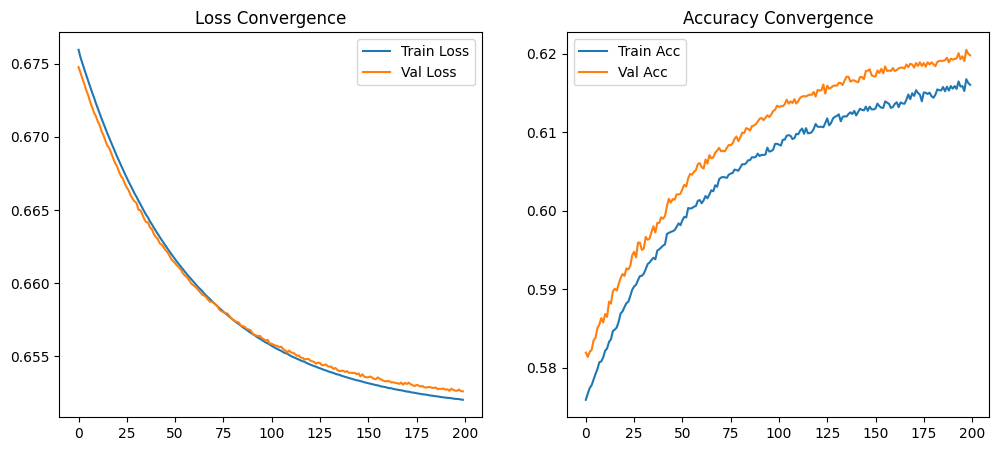

In [19]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Convergence')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Convergence')
plt.legend()
plt.show()

In [20]:
test_pred = predict(X_test, theta)
test_acc = np.mean((test_pred >= 0.5).astype(int) == y_test)
print(f"Accuracy trên tập Test: {test_acc * 100:.2f}%")

Accuracy trên tập Test: 62.38%
